# Train and evaluate LightGBM Regressor

Trains `MultiOutputRegressor(LGBMRegressor(...))` on each of the 3 folds (`src/forecast/
LightGBM_Regressor.py`), evaluates with `src/common/metrics.py`, and consolidates results across
folds. Loads `fsa_hourly_features.parquet` and saves the predictions for reuse as a feature in
the peak-risk classifier.

In [1]:
# Jupyter's cwd is the notebook's folder, not the repo root, so "from src.common..." below
# needs the repo root on sys.path. This walks up parent folders until it finds requirements.txt
# (which only exists at the repo root) and adds that folder to sys.path.
import sys
from pathlib import Path

def find_repo_root(start: Path) -> Path:
    for parent in [start, *start.parents]:
        if (parent / "requirements.txt").exists():
            return parent
    raise FileNotFoundError("Could not locate repo root (requirements.txt not found)")


REPO_ROOT = find_repo_root(Path.cwd())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

REPO_ROOT

WindowsPath('C:/workspace/CAPSTONE/ontario-electricity-peak-risk')

In [2]:
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.common.data_loading import INTERIM_DIR, save_interim_dataset
from src.common.folds import FOLDS, split_fold
from src.common.metrics import metrics_by_group, metrics_by_horizon, summary_metrics
from src.common.peak_risk import compute_peak_thresholds, label_peaks
from src.forecast.LightGBM_Regressor import predict_long_format, train_fold

pd.set_option("display.max_columns", 50)

## 1. Load the engineered dataset

Loads `fsa_hourly_features.parquet`, the lags/rolling stats/multi-output targets built in the
previous notebook.

In [3]:
dataset = pd.read_parquet(INTERIM_DIR / "fsa_hourly_features.parquet")
dataset.shape

(262944, 88)

## 2. Train and predict, one fold at a time

For each fold: train on that fold's training split, predict on its test split, and reshape to
the forecast output contract (`fsa`, `origin_timestamp`, `forecast_timestamp`, `horizon`,
`actual`, `prediction`, `model_name`). `actual` is NaN for the handful of rows at the very end of
2025 (fold 3) with no future data to score against; `summary_metrics` drops those automatically.

In [4]:
fold_forecasts = []
fold_summary = []
for fold in FOLDS:
    t0 = time.time()
    model, feature_columns, test = train_fold(dataset, fold)
    train_seconds = time.time() - t0

    forecast = predict_long_format(model, feature_columns, test)
    forecast.insert(0, "fold", fold.number)
    fold_forecasts.append(forecast)

    fold_summary.append(
        {
            "fold": fold.number,
            "test_year": fold.test_year,
            "train_seconds": round(train_seconds, 1),
            "n_predictions": len(forecast),
            "n_missing_actual": int(forecast["actual"].isna().sum()),
            **summary_metrics(forecast),
        }
    )

all_forecasts = pd.concat(fold_forecasts, ignore_index=True)
pd.DataFrame(fold_summary)

,fold,test_year,train_seconds,n_predictions,n_missing_actual,mae,wape,rmse,mape
0,1,2023,17.8,1261440,0,612.743500,0.067889,1050.378085,6.467014
1,2,2024,22.7,1264896,0,517.277292,0.056390,823.050747,5.699075
2,3,2025,36.0,1261440,1800,554.988446,0.057410,940.925303,5.715442


## 3. Aggregated metrics across folds

Mean, median, and standard deviation of each metric across the 3 folds, to see how much
performance varies with the fold rather than just reading off a single number.

In [5]:
per_fold_metrics = pd.DataFrame(fold_summary)[["mae", "wape", "rmse", "mape"]]
per_fold_metrics.agg(["mean", "median", "std"]).round(4)

,mae,wape,rmse,mape
mean,561.6697,0.0606,938.1180,5.9605
median,554.9884,0.0574,940.9253,5.7154
std,48.0825,0.0064,113.6897,0.4387


## 4. Error by forecast horizon

WAPE per horizon (h+1..h+24), per fold. Error climbs from h+1 toward a plateau around h+15-18,
then eases back down toward h+24, where the next-day daily cycle (`consumption_lag_24h`) starts
helping the model again. Peaks and the shared low point (h+1) are labeled directly on the chart;
the exact value per horizon is in the table below it.

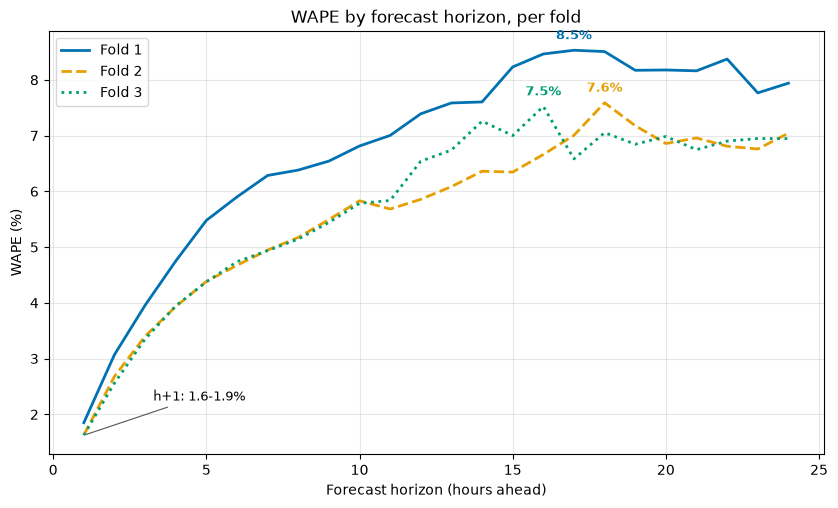

In [6]:
horizon_by_fold = {
    fold.number: metrics_by_horizon(all_forecasts[all_forecasts["fold"] == fold.number])
    for fold in FOLDS
}

colors = {1: "#0072B2", 2: "#E69F00", 3: "#009E73"}
linestyles = {1: "-", 2: "--", 3: ":"}

fig, ax = plt.subplots(figsize=(10, 5.5))
for fold_number, horizon_metrics in horizon_by_fold.items():
    wape_pct = horizon_metrics["wape"] * 100
    ax.plot(
        horizon_metrics["horizon"],
        wape_pct,
        label=f"Fold {fold_number}",
        color=colors[fold_number],
        linestyle=linestyles[fold_number],
        linewidth=2,
    )
    peak_row = wape_pct.idxmax()
    peak_h, peak_v = horizon_metrics.loc[peak_row, "horizon"], wape_pct.loc[peak_row]
    ax.annotate(
        f"{peak_v:.1f}%",
        xy=(peak_h, peak_v),
        xytext=(0, 8),
        textcoords="offset points",
        ha="center",
        fontsize=9,
        color=colors[fold_number],
        fontweight="bold",
    )

# all 3 folds bottom out at h+1 - one shared label instead of 3 overlapping ones
low_values = [horizon_metrics["wape"].iloc[0] * 100 for horizon_metrics in horizon_by_fold.values()]
ax.annotate(
    f"h+1: {min(low_values):.1f}-{max(low_values):.1f}%",
    xy=(1, min(low_values)),
    xytext=(50, 25),
    textcoords="offset points",
    ha="left",
    fontsize=9,
    arrowprops=dict(arrowstyle="-", color="#555555", lw=0.8),
)

ax.set_xlabel("Forecast horizon (hours ahead)")
ax.set_ylabel("WAPE (%)")
ax.set_title("WAPE by forecast horizon, per fold")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

In [7]:
horizon_table = pd.DataFrame(
    {f"fold_{n}_wape_pct": (hm["wape"] * 100).round(2).to_numpy() for n, hm in horizon_by_fold.items()},
    index=horizon_by_fold[1]["horizon"].to_numpy(),
)
horizon_table.index.name = "horizon"
horizon_table

,fold_1_wape_pct,fold_2_wape_pct,fold_3_wape_pct
horizon,,,
1,1.85,1.63,1.63
2,3.07,2.68,2.56
3,3.96,3.40,3.35
4,4.75,3.93,3.95
5,5.48,4.38,4.38
6,5.90,4.67,4.74
7,6.28,4.95,4.94
8,6.38,5.17,5.14
9,6.54,5.49,5.44


## 5. Verify the 144-prediction contract

Every origin timestamp should produce exactly 144 predictions: 6 FSA x 24 horizons, from one
`.predict()` call. Checked below across every origin timestamp in all 3 folds combined.

In [8]:
run_sizes = all_forecasts.groupby(["fold", "origin_timestamp"], observed=True).size()
assert (run_sizes == 144).all(), "every origin timestamp should produce 6 FSA x 24 horizons"
print(len(run_sizes), "origin timestamps checked, all with 144 predictions")

26304 origin timestamps checked, all with 144 predictions


Same 144 predictions from one run, as a grid instead of a count: FSA rows, horizon columns,
darker = higher predicted consumption, values annotated in each cell. The highlighted cell in
each row is that FSA's own highest-consumption horizon.

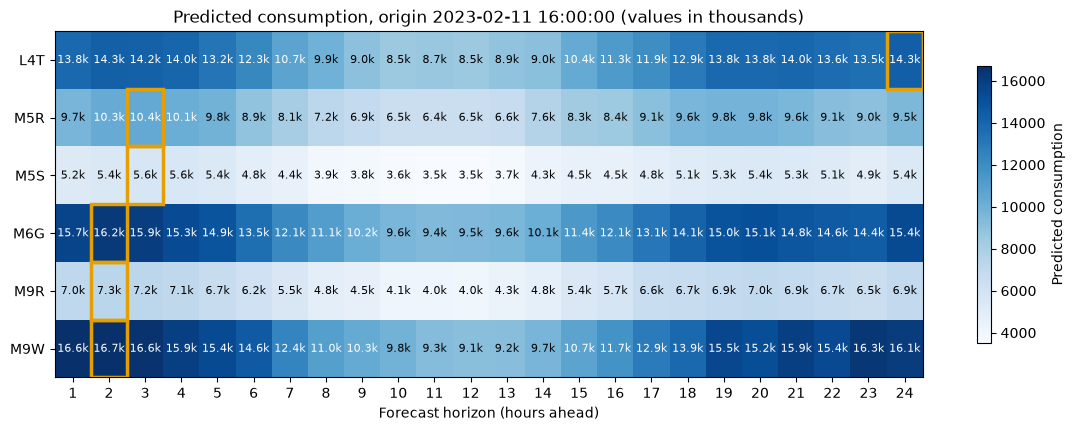

In [9]:
example_origin = sorted(all_forecasts.loc[all_forecasts["fold"] == 1, "origin_timestamp"].unique())[1000]
example_run = all_forecasts[
    (all_forecasts["fold"] == 1) & (all_forecasts["origin_timestamp"] == example_origin)
].sort_values(["fsa", "horizon"])

pivot = example_run.pivot(index="fsa", columns="horizon", values="prediction").sort_index()
values = pivot.to_numpy()
vmin, vmax = values.min(), values.max()
midpoint = (vmin + vmax) / 2

fig, ax = plt.subplots(figsize=(14, 4.5))
im = ax.imshow(values, cmap="Blues", aspect="auto", vmin=vmin, vmax=vmax)

for row_index in range(values.shape[0]):
    for col_index in range(values.shape[1]):
        value = values[row_index, col_index]
        text_color = "white" if value > midpoint else "black"
        ax.text(
            col_index, row_index, f"{value / 1000:.1f}k",
            ha="center", va="center", color=text_color, fontsize=8,
        )

for row_index, fsa in enumerate(pivot.index):
    col_index = pivot.loc[fsa].to_numpy().argmax()
    ax.add_patch(
        plt.Rectangle((col_index - 0.5, row_index - 0.5), 1, 1, fill=False, edgecolor="#E69F00", linewidth=2.5)
    )

ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
ax.set_xlabel("Forecast horizon (hours ahead)")
ax.set_title(f"Predicted consumption, origin {example_origin} (values in thousands)")
fig.colorbar(im, ax=ax, label="Predicted consumption", shrink=0.8)
plt.show()

All 6 zones follow the same daily rhythm here: consumption climbs in the early evening, drops
off overnight, and builds back up by the next afternoon. Five of the six peak within the first
few hours after the 4pm origin; L4T is the one exception, peaking a full day later at the same
hour instead. How much each zone swings between its high and low also lines up with the size
split from the Day 2 EDA: M9W and M6G move the most (over 6,800 kWh between peak and trough),
while M5S, the smallest zone, barely moves by comparison (about 2,100 kWh).

## 6. Example run: one origin timestamp, all 6 FSA

One origin timestamp from fold 1's test split, actual vs. predicted consumption across all 24
horizons, one panel per FSA. This is what a single forecast run actually looks like, instead of
metrics pooled across every FSA and every hour.

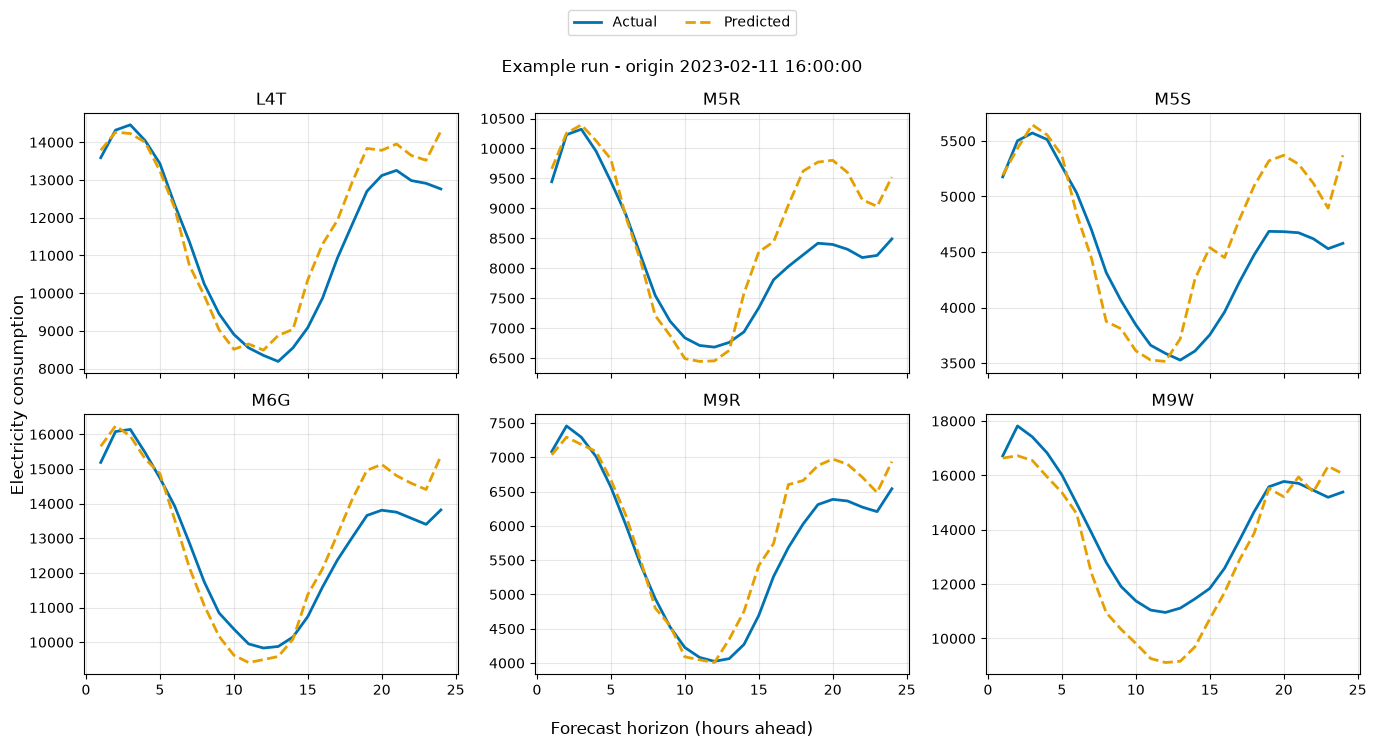

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharex=True)
for ax, fsa in zip(axes.flat, sorted(example_run["fsa"].unique())):
    fsa_run = example_run[example_run["fsa"] == fsa]
    ax.plot(fsa_run["horizon"], fsa_run["actual"], label="Actual", color="#0072B2", linewidth=2)
    ax.plot(
        fsa_run["horizon"], fsa_run["prediction"], label="Predicted",
        color="#E69F00", linestyle="--", linewidth=2,
    )
    ax.set_title(fsa)
    ax.grid(True, alpha=0.3)

fig.supxlabel("Forecast horizon (hours ahead)")
fig.supylabel("Electricity consumption")
fig.suptitle(f"Example run - origin {example_origin}")
handles, labels = axes.flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1.06))
plt.tight_layout()
plt.show()

## 7. Error by FSA

MAE/WAPE/RMSE/MAPE per FSA, pooled across all 3 folds, to see whether any zone is harder to
forecast than the rest instead of only looking at the pooled and per-horizon views above.

In [11]:
metrics_by_group(all_forecasts, "fsa")

,fsa,mae,wape,rmse,mape
0,L4T,661.584851,0.056705,1062.398699,5.314392
1,M5R,458.542418,0.059621,657.155847,5.939276
2,M5S,252.584318,0.061673,346.795437,6.323183
3,M6G,635.471753,0.053142,961.708348,5.185734
4,M9R,404.168754,0.070335,636.585973,6.812066
5,M9W,957.442300,0.065703,1523.157914,6.187678


## 8. Error during peak hours

The plan calls for checking accuracy specifically during high-demand hours, not just averaged
over every hour. "Peak" here uses the same definition as the classifier's ground truth
(`src/common/peak_risk.py`): consumption above the 97.5th percentile for that FSA and season,
with the threshold computed only from each fold's training years, same as in the Día 3 notebook.

In [12]:
peak_labeled = []
for fold in FOLDS:
    train, _ = split_fold(dataset, fold, timestamp_column="timestamp_local")
    thresholds = compute_peak_thresholds(train)
    labeled = label_peaks(dataset, thresholds)[["fsa", "timestamp_local", "actual_peak"]]

    fold_forecast = all_forecasts[all_forecasts["fold"] == fold.number].merge(
        labeled,
        left_on=["fsa", "forecast_timestamp"],
        right_on=["fsa", "timestamp_local"],
        how="left",
    )
    peak_labeled.append(fold_forecast)

all_forecasts_labeled = pd.concat(peak_labeled, ignore_index=True).dropna(subset=["actual_peak"])

peak_summary = metrics_by_group(all_forecasts_labeled, "actual_peak")
peak_summary["actual_peak"] = peak_summary["actual_peak"].map({0: "Non-peak", 1: "Peak"})
peak_counts = all_forecasts_labeled["actual_peak"].value_counts().rename({0: "Non-peak", 1: "Peak"})
peak_summary["n_predictions"] = peak_summary["actual_peak"].map(peak_counts)
peak_summary

,actual_peak,mae,wape,rmse,mape,n_predictions
0,Non-peak,495.354835,0.056494,772.190434,5.791323,3509625
1,Peak,1403.349626,0.088291,2144.658937,8.107500,276351


Same comparison, broken out by fold, to check the pattern holds across all 3 rather than being
a one-off.

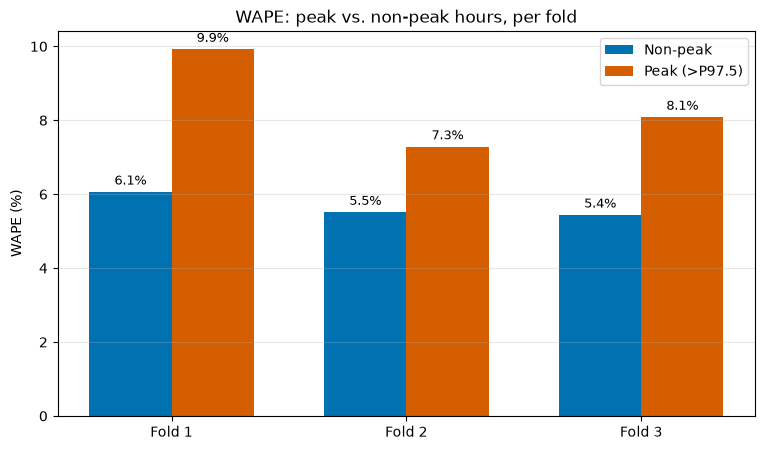

In [13]:
peak_by_fold = []
for fold in FOLDS:
    fold_data = all_forecasts_labeled[all_forecasts_labeled["fold"] == fold.number]
    for is_peak, group in fold_data.groupby("actual_peak"):
        peak_by_fold.append(
            {
                "fold": fold.number,
                "hour_type": "Peak" if is_peak == 1 else "Non-peak",
                **summary_metrics(group),
            }
        )
peak_by_fold_df = pd.DataFrame(peak_by_fold)

fold_numbers = [fold.number for fold in FOLDS]
nonpeak_wape = (
    peak_by_fold_df.loc[peak_by_fold_df["hour_type"] == "Non-peak"].set_index("fold").loc[fold_numbers, "wape"]
    * 100
).to_numpy()
peak_wape = (
    peak_by_fold_df.loc[peak_by_fold_df["hour_type"] == "Peak"].set_index("fold").loc[fold_numbers, "wape"] * 100
).to_numpy()

x = np.arange(len(fold_numbers))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars_nonpeak = ax.bar(x - width / 2, nonpeak_wape, width, label="Non-peak", color="#0072B2")
bars_peak = ax.bar(x + width / 2, peak_wape, width, label="Peak (>P97.5)", color="#D55E00")

for bars in (bars_nonpeak, bars_peak):
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, height + 0.2, f"{height:.1f}%", ha="center", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels([f"Fold {n}" for n in fold_numbers])
ax.set_ylabel("WAPE (%)")
ax.set_title("WAPE: peak vs. non-peak hours, per fold")
ax.grid(axis="y", alpha=0.3)
ax.legend()
plt.show()

Peak hours are consistently harder to forecast, in all 3 folds: WAPE roughly 1.3-1.6x higher
than non-peak hours (9.9% vs. 6.1% in fold 1, 7.3% vs. 5.5% in fold 2, 8.1% vs. 5.4% in fold 3).
Pooled across all 3 folds, non-peak WAPE is 5.6% against 8.8% for peak hours. This matches a
known tendency of tree-based models: they pull extreme values back toward what they saw in
training, so the sharpest demand spikes get underestimated more than an ordinary hour would.
Worth keeping in mind for the peak-risk classifier next, since it will use this regressor's
forecast as one of its own inputs, and that input is least reliable exactly during the hours
that matter most.

## 9. Hyperparameter tuning: default vs. tuned

Tried a higher-capacity, regularized config against the default (`num_leaves=127`,
`n_estimators=300`, `learning_rate=0.05`, plus L1/L2 regularization and row/column
subsampling). Picked using an internal 2021-train/2022-validate split, not any of the 3
official folds, so none of the results below were used to choose it.

In [14]:
TUNED_PARAMS = dict(
    num_leaves=127,
    n_estimators=300,
    learning_rate=0.05,
    reg_alpha=0.1,
    reg_lambda=0.1,
    subsample=0.8,
    subsample_freq=1,
    colsample_bytree=0.8,
)

tuned_forecasts = []
tuned_summary = []
for fold in FOLDS:
    t0 = time.time()
    model, feature_columns, test = train_fold(dataset, fold, model_params=TUNED_PARAMS)
    train_seconds = time.time() - t0

    forecast = predict_long_format(model, feature_columns, test, model_name="LightGBM_Regressor_tuned")
    forecast.insert(0, "fold", fold.number)
    tuned_forecasts.append(forecast)

    tuned_summary.append(
        {
            "fold": fold.number,
            "test_year": fold.test_year,
            "train_seconds": round(train_seconds, 1),
            **summary_metrics(forecast),
        }
    )

all_forecasts_tuned = pd.concat(tuned_forecasts, ignore_index=True)

comparison = pd.concat(
    [
        pd.DataFrame(fold_summary)[["fold", "test_year", "mae", "wape", "rmse", "mape"]].assign(model="default"),
        pd.DataFrame(tuned_summary)[["fold", "test_year", "mae", "wape", "rmse", "mape"]].assign(model="tuned"),
    ]
).sort_values(["fold", "model"]).reset_index(drop=True)
comparison

,fold,test_year,mae,wape,rmse,mape,model
0,1,2023,612.743500,0.067889,1050.378085,6.467014,default
1,1,2023,578.797760,0.064128,1073.247609,5.770309,tuned
2,2,2024,517.277292,0.056390,823.050747,5.699075,default
3,2,2024,473.797678,0.051650,804.252791,5.061305,tuned
4,3,2025,554.988446,0.057410,940.925303,5.715442,default
5,3,2025,510.477847,0.052806,924.043874,5.083147,tuned


Tuned wins on pooled metrics in every fold. Since this project cares about peak-hour accuracy
specifically (section 8), the same comparison is repeated split by peak/non-peak hours.

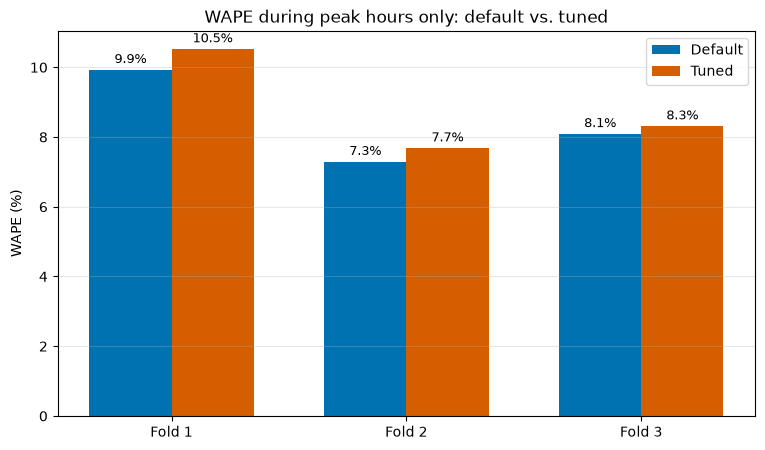

In [15]:
peak_labeled_tuned = []
for fold in FOLDS:
    train, _ = split_fold(dataset, fold, timestamp_column="timestamp_local")
    thresholds = compute_peak_thresholds(train)
    labeled = label_peaks(dataset, thresholds)[["fsa", "timestamp_local", "actual_peak"]]

    fold_forecast = all_forecasts_tuned[all_forecasts_tuned["fold"] == fold.number].merge(
        labeled,
        left_on=["fsa", "forecast_timestamp"],
        right_on=["fsa", "timestamp_local"],
        how="left",
    )
    peak_labeled_tuned.append(fold_forecast)

all_forecasts_tuned_labeled = pd.concat(peak_labeled_tuned, ignore_index=True).dropna(subset=["actual_peak"])

peak_wape_default = [
    summary_metrics(all_forecasts_labeled[(all_forecasts_labeled["fold"] == n) & (all_forecasts_labeled["actual_peak"] == 1)])["wape"] * 100
    for n in fold_numbers
]
peak_wape_tuned = [
    summary_metrics(all_forecasts_tuned_labeled[(all_forecasts_tuned_labeled["fold"] == n) & (all_forecasts_tuned_labeled["actual_peak"] == 1)])["wape"] * 100
    for n in fold_numbers
]

x = np.arange(len(fold_numbers))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars_default = ax.bar(x - width / 2, peak_wape_default, width, label="Default", color="#0072B2")
bars_tuned = ax.bar(x + width / 2, peak_wape_tuned, width, label="Tuned", color="#D55E00")

for bars in (bars_default, bars_tuned):
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, height + 0.2, f"{height:.1f}%", ha="center", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels([f"Fold {n}" for n in fold_numbers])
ax.set_ylabel("WAPE (%)")
ax.set_title("WAPE during peak hours only: default vs. tuned")
ax.grid(axis="y", alpha=0.3)
ax.legend()
plt.show()

The tuned config loses on peak hours in all 3 folds: it trades peak accuracy for non-peak
accuracy, since the extra capacity and regularization pull predictions toward the typical range
instead of chasing the rare extremes.

**Decision: kept the default.** For a peak-risk system, accuracy during high-demand hours
matters more than the pooled average, so `build_model()`'s defaults stay unchanged
(`model_params` remains available as an override). Revisiting this later would need something
aimed at peak hours specifically, like sample weighting or a quantile objective, not generic
tuning.

## 10. Save predictions

Saves the long-format predictions from all 3 folds (default config, the one kept) to
`data/interim/lightgbm_regressor_predictions.parquet`, so the peak-risk classifier can join the
forecasted consumption in as a feature instead of retraining the regressor.

In [16]:
output_path = save_interim_dataset(all_forecasts, filename="lightgbm_regressor_predictions.parquet")
output_path

WindowsPath('C:/workspace/CAPSTONE/ontario-electricity-peak-risk/data/interim/lightgbm_regressor_predictions.parquet')